# The Research Agent

**Docker image**: `ml4t`

The first three notebooks built the pieces separately: a model client, a search tool with a
cutoff and a source policy, and a state record with gates over it. This notebook assembles
them into one object that takes a question and returns a probability with everything behind
it attached, which is the unit every later notebook in the chapter operates on.

**Learning Objectives**:
- Assemble a model client, a search tool and a turn budget into one agent that answers a
  question end to end
- Parse and validate a model reply that arrives fenced, prefixed, or in the wrong shape, and
  return it for correction instead of failing
- Derive confidence, sentiment, evidence class and key findings from a forecast in code, so
  that every agent's metadata is produced the same way
- Tell an agent that committed to a probability apart from one that ran out of turns, and
  keep the second out of any average
- Read a saved run record and reproduce a forecast made months earlier with no API calls

**Book Reference**: Chapter 24, Section 24.6 (Designing the research agent at the heart of
the pipeline)

**Prerequisites**: [`01_react_reasoning`](01_react_reasoning.ipynb) (providers),
[`02_tool_contracts`](02_tool_contracts.ipynb) (tools),
[`03_state_and_memory`](03_state_and_memory.ipynb) (state and gates).

In [1]:
"""The Research Agent: ReAct loop with structured output extraction."""

import re
from dataclasses import dataclass, field
from datetime import date, datetime

import matplotlib.pyplot as plt
import polars as pl
from agent_fixtures import get_chapter_contested_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    merge_calls,
    show_agent_timeline,
    trace_llm,
)
from agent_providers import ChatMessage, LLMClient, TokenUsage, create_llm_client
from agent_research import extract_confidence, parse_json, validate_action
from agent_schemas import (
    AgentForecastArtifact,
    AgentState,
    AgentTrace,
    EvidenceQuality,
    ForecastQuestion,
    Sentiment,
    run_quality_gates,
)
from agent_tools import (
    SearchClient,
    ToolExecutor,
    create_search_client,
    format_search_results,
)

from utils.style import COLORS, add_message_title, format_pct_axis, show_with_alt

## Settings

`RUN_LIVE` left at `False` replays the pinned 2026-06-09 capture named below: the notebook
reloads that saved run and makes no API calls, so the agent's output is fixed and matches the
chapter's discussion of it. `True` forecasts a current question against live search, which
costs money and will not reproduce these values.

`MAX_STEPS` is the turn budget, as in
[`01_react_reasoning`](01_react_reasoning.ipynb). `MAX_SEARCH_RESULTS` caps how many
documents one search returns; five keeps a handful of searches inside the context window.
`LLM_PROVIDER` is empty so the factory picks whichever provider has a key, and is read only
on the live path.

In [2]:
RUN_LIVE = False
PINNED_TRACE = "04_research_agent_20260609T141730Z_b694ab4d0453.json"
LLM_PROVIDER = ""
MAX_STEPS = 5
MAX_SEARCH_RESULTS = 5

## Prompt Templates

The system prompt fixes the agent's role and its two hard constraints: emit valid JSON, and
do not go looking for the market's own price. The second matters for evaluation. An agent
that reads the prediction market it is being scored against is copying, and the copy will
score well, so the constraint is stated to the model and then verified against the saved
prompts further down rather than trusted.

In [3]:
AGENT_SYSTEM_PROMPT = """\
You are a forecasting agent in a multi-agent forecasting system.

Your job:
1) Gather evidence by issuing web/news search queries when needed.
2) Then produce a binary probability forecast for the question.

You must follow the action schema exactly and output valid JSON only.
You must not browse prediction market prices unless they are explicitly provided."""

### Step prompt

Provides the question, optional market context, and the action schema.
The agent must output exactly one JSON action per step.

In [4]:
def build_step_prompt(
    question: ForecastQuestion,
    market_price: float | None = None,
) -> str:
    """Format the step prompt with question context."""
    prompt = f"QUESTION:\n{question.question}\n\n"
    if question.description:
        prompt += f"MARKET CONTEXT:\n{question.description}\n\n"
    if market_price is not None:
        prompt += f"MARKET IMPLIED PROBABILITY (p_yes):\n{market_price}\n\n"
    prompt += (
        "NEXT ACTION SCHEMA (output JSON only):\n"
        'If you need more info:\n{"action":"search","query":"..."}\n'
        "If you are ready to forecast:\n"
        '{"action":"forecast","p_yes":0.XX,"rationale":"short explanation '
        'grounded in evidence and base rates"}\n\n'
        "Pick exactly one action."
    )
    return prompt

## Parsing and Validating the Model's Reply

A model told to emit JSON emits JSON most of the time. The rest of the time it wraps the
object in a markdown fence, adds a sentence of explanation before it, or returns something
well-formed that is not an action. All three are ordinary, none is an error condition, and
an agent that crashes on them is an agent that cannot be run unattended.

`parse_json` accepts exactly one JSON object, fenced or bare, and turns anything else into an
explicit parse-failure action. `validate_action` then checks the object against the two
documented schemas: a search needs a non-empty string query, a forecast needs a finite
numeric `p_yes` and a string rationale, and probabilities are clamped to $[0, 1]$ before
anything acts on them. A reply failing either check costs a turn and is returned to the model
for correction.

Both come from `agent_research.py` rather than being written here, because every agent in the
chapter has to reject the same shapes the same way: a parser that differs between notebooks
is a source of disagreement that looks like a difference of judgement.

## Derived Fields

The model returns a probability and a rationale. Everything else on the artifact is computed
from those two by the functions below. Keeping the derivation in code rather than asking the
model for it means every agent's metadata is produced the same way, which is what makes
agents comparable; it also means the fields are exactly as good as their definitions, and
several of these definitions are crude on purpose. They are labelled as heuristics wherever
they are printed.

### Confidence

When the model volunteers a `confidence` field it is used, clamped to $[0, 1]$. Otherwise
confidence is taken as distance from even odds,
$\text{confidence} = 2\,\lvert p_{\text{yes}} - \tfrac{1}{2} \rvert$, which is zero at
even odds and one at either certainty.

That is a statement about the probability's position, not about the evidence behind it. An
agent that read forty documents and concluded the question is genuinely balanced scores zero;
is uniform and cheap. What would answer the question instead is calibration: whether
probabilities stated at seventy percent come true about seventy percent of the time.
[`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb) builds that arithmetic
and runs it on synthetic inputs, because measuring it for real needs forecasts recorded
before their questions resolved, which no capture in this chapter has.

### Sentiment extraction

Maps $p_{\text{yes}}$ mechanically to a five-level sentiment scale.

In [5]:
def extract_sentiment(p_yes: float) -> Sentiment:
    """Infer sentiment from probability."""
    if p_yes > 0.8:
        return Sentiment.STRONGLY_BULLISH
    if p_yes > 0.6:
        return Sentiment.BULLISH
    if p_yes > 0.4:
        return Sentiment.NEUTRAL
    if p_yes > 0.2:
        return Sentiment.BEARISH
    return Sentiment.STRONGLY_BEARISH

### Key findings and uncertainties

Parses bullet points and numbered items from the rationale text, and identifies
sentences containing uncertainty language.

In [6]:
def extract_key_findings(rationale: str) -> list[str]:
    """Extract bullet points and numbered items from rationale."""
    findings = []
    for line in rationale.split("\n"):
        line = line.strip()
        if re.match(r"^[-•*]\s+", line):
            findings.append(re.sub(r"^[-•*]\s+", "", line).strip())
        elif re.match(r"^\d+[.)]\s+", line):
            findings.append(re.sub(r"^\d+[.)]\s+", "", line).strip())
    return findings[:10]

### Uncertainty extraction

Identifies sentences containing uncertainty language in the rationale.

In [7]:
def extract_uncertainties(rationale: str) -> list[str]:
    """Identify sentences mentioning uncertainty."""
    uncertainty_words = {
        "uncertain",
        "unclear",
        "unknown",
        "risk",
        "caveat",
        "however",
        "but",
        "although",
    }
    sentences = re.split(r"[.!?]+", rationale)
    return [
        s.strip() for s in sentences if s.strip() and any(w in s.lower() for w in uncertainty_words)
    ][:5]

### Evidence quality assessment

This volume heuristic uses only query and result counts. It does not validate
source credibility, independence, or point-in-time availability.

In [8]:
def assess_evidence_quality(sources_consulted: int, queries_made: int) -> EvidenceQuality:
    """Classify evidence volume from query and result counts."""
    if sources_consulted >= 10 and queries_made >= 3:
        return EvidenceQuality.HIGH
    if sources_consulted >= 5 or queries_made >= 2:
        return EvidenceQuality.MEDIUM
    return EvidenceQuality.LOW

## ReAct step handlers

The ReAct loop processes one of three action types per step: a search,
a forecast, or an unrecognised action. Extracting each branch as a small
free function keeps the agent class focused on iteration and assembly.

In [9]:
def _handle_search_step(
    executor,
    action: dict,
    cutoff,
    max_search_results: int,
    messages: list[ChatMessage],
    traces: list[AgentTrace],
    step: int,
    response: str,
) -> tuple[int, int]:
    """Execute a search action, append to messages + traces. Returns (queries_inc, sources_inc)."""
    query = action.get("query", "")
    results = executor.execute_search(query, max_results=max_search_results, cutoff_date=cutoff)
    traces.append(
        AgentTrace(step=step, action="search", query=query, results=results, llm_raw=response)
    )
    messages.append(ChatMessage(role="assistant", content=response))
    messages.append(ChatMessage(role="tool", content=format_search_results(results)))
    return 1, len(results)

### Forecast handler

In [10]:
def _handle_forecast_step(
    action: dict,
    traces: list[AgentTrace],
    step: int,
    response: str,
) -> tuple[float, str, dict]:
    """Record a forecast action. Returns (p_yes, rationale, raw_action)."""
    p_yes = action["p_yes"]
    rationale = action["rationale"]
    traces.append(AgentTrace(step=step, action="forecast", llm_raw=response))
    return p_yes, rationale, action

### Unknown-action handler

In [11]:
def _handle_unknown_step(
    action_type: str,
    response: str,
    messages: list[ChatMessage],
    traces: list[AgentTrace],
    step: int,
) -> None:
    """Record an unrecognized action and feed an error back to the LLM."""
    traces.append(AgentTrace(step=step, action=action_type, llm_raw=response))
    messages.append(ChatMessage(role="assistant", content=response))
    messages.append(
        ChatMessage(
            role="tool",
            content=f"Error: unrecognized action '{action_type}'. Use 'search' or 'forecast'.",
        )
    )

## Loop State and Assembly

Explicit loop state keeps iteration separate from artifact construction.

In [12]:
@dataclass
class _LoopResult:
    """Mutable state accumulated by one ReAct loop."""

    p_yes: float = 0.5
    rationale: str = ""
    forecast_produced: bool = False
    raw_action: dict = field(default_factory=dict)
    traces: list[AgentTrace] = field(default_factory=list)
    total_tokens: TokenUsage = field(default_factory=TokenUsage)
    queries_made: int = 0
    sources_consulted: int = 0

### Artifact assembly

In [13]:
def _assemble_artifact(agent, result: _LoopResult) -> AgentForecastArtifact:
    """Convert loop state into the structured forecast artifact."""
    return AgentForecastArtifact(
        agent_id=agent.agent_id,
        p_yes=result.p_yes,
        rationale=result.rationale,
        traces=result.traces,
        forecast_produced=result.forecast_produced,
        confidence=extract_confidence(result.raw_action),
        sentiment=extract_sentiment(result.p_yes),
        key_findings=extract_key_findings(result.rationale),
        evidence_quality=assess_evidence_quality(
            result.sources_consulted,
            result.queries_made,
        ),
        uncertainties=extract_uncertainties(result.rationale),
        token_usage=result.total_tokens,
        search_queries_made=result.queries_made,
        sources_consulted=result.sources_consulted,
    )

### ReAct loop

In [14]:
def _run_research_loop(
    agent,
    question: ForecastQuestion,
    market_price: float | None,
) -> AgentForecastArtifact:
    cutoff = date.fromisoformat(question.cutoff_date) if question.cutoff_date else None
    messages = [
        ChatMessage(role="system", content=AGENT_SYSTEM_PROMPT),
        ChatMessage(role="user", content=build_step_prompt(question, market_price)),
    ]
    result = _LoopResult()

    for step in range(1, agent.max_steps + 1):
        response, usage = agent.llm.complete_with_usage(messages, json_mode=True)
        result.total_tokens = result.total_tokens + usage
        parsed = parse_json(response)
        action_type, action = validate_action(parsed)

        if action_type == "search" and action is not None:
            dq, ds = _handle_search_step(
                agent.executor,
                action,
                cutoff,
                agent.max_search_results,
                messages,
                result.traces,
                step,
                response,
            )
            result.queries_made += dq
            result.sources_consulted += ds
        elif action_type == "forecast" and action is not None:
            result.p_yes, result.rationale, result.raw_action = _handle_forecast_step(
                action, result.traces, step, response
            )
            result.forecast_produced = True
            break
        else:
            _handle_unknown_step(action_type, response, messages, result.traces, step)
    else:
        # The budget ran out with no forecast action. result.p_yes keeps its initial
        # value; forecast_produced stays False so nothing downstream reads it as a
        # judgement.
        result.rationale = "Max steps reached without forecast"
        result.traces.append(AgentTrace(step=agent.max_steps, action="forced_default"))

    return _assemble_artifact(agent, result)

## The ResearchAgent Class

The class owns three things and no logic: the model client, the tool executor, and the two
budgets. `run()` hands them to the loop above. `agent_research.py` carries the same agent for
the notebooks that import it rather than rebuild it, which is why the pieces are laid out
separately here: this is the one notebook where the contract is read rather than called.

In [15]:
class ResearchAgent:
    """ReAct-based research agent producing probability forecasts.

    Implements the same loop as the AIA Forecaster's research agent:
    search for evidence, then forecast with rich metadata.
    """

    def __init__(
        self,
        llm: LLMClient,
        search: SearchClient | None = None,
        agent_id: str = "agent_0",
        max_steps: int = 5,
        max_search_results: int = 5,
    ) -> None:
        self.llm = llm
        self.executor = ToolExecutor(search=search)
        self.agent_id = agent_id
        self.max_steps = max_steps
        self.max_search_results = max_search_results

    def run(
        self,
        question: ForecastQuestion,
        market_price: float | None = None,
    ) -> AgentForecastArtifact:
        """Run the agent on a question and return its forecast artifact."""
        return _run_research_loop(self, question, market_price)

## Running the Research Agent

The question is `CHAPTER_CONTESTED_QUESTION` from `agent_fixtures.py`: *"Will the Federal
Reserve hike rates in 2026?"*. It is contested in the specific sense that matters here, which
is that two runs of the same agent reach opposite conclusions on it, so it is the question
the chapter uses wherever disagreement is the subject.
[`07_adversarial_debate`](07_adversarial_debate.ipynb) makes agents argue about it and
[`08_forecasting_pipeline`](08_forecasting_pipeline.ipynb) runs the full pipeline on it.
[`06_multi_agent_research`](06_multi_agent_research.ipynb) uses the companion
`CHAPTER_CLEAR_QUESTION` instead, where the agents agree, so the two can be compared.

On the default path the notebook replays the pinned capture rather than calling anything:
provider `claude-sonnet-4`, Tavily search, recorded 2026-06-09. Setting `RUN_LIVE = True`
with `ANTHROPIC_API_KEY` and `TAVILY_API_KEY` forecasts a current question instead, and will
not reproduce the values below.

In [16]:
if RUN_LIVE:
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)

    # Wrap the client in a TracingLLMClient so every prompt and raw response is
    # captured for the run trace we persist at the end of the notebook.
    tracer_0 = trace_llm(llm, label="agent_0")
    agent = ResearchAgent(
        llm=tracer_0,
        search=search,
        agent_id="agent_0",
        max_steps=MAX_STEPS,
        max_search_results=MAX_SEARCH_RESULTS,
    )

    question = get_chapter_contested_question()
    provider_name = llm.model_name
    search_name = type(search).__name__
    artifact = agent.run(question)
else:
    # Replay: reload the pinned trace and rehydrate its two saved agents. The
    # first is the single-agent forecast inspected here; the second is the
    # preview pair shown later. Display cells consume these unchanged.
    pinned_run = RunTrace.load(TRACES_DIR / PINNED_TRACE)
    question = pinned_run.question_obj()
    provider_name = pinned_run.provider
    search_name = "replay (pinned trace)"
    replayed_artifacts = pinned_run.agent_artifacts()
    artifact = replayed_artifacts[0]

print(f"Mode: {'LIVE' if RUN_LIVE else 'REPLAY (pinned 2026-06-09 trace)'}")
print(f"Provider: {provider_name}")
print(f"Search: {search_name}")
print(f"Question: {question.question}\n")

Mode: REPLAY (pinned 2026-06-09 trace)
Provider: claude-sonnet-4-20250514
Search: replay (pinned trace)
Question: Will the Federal Reserve hike rates in 2026?



### What the pinned trace does and does not establish

The replay is a recording of one live run, which makes it reproducible and does not make it a
backtest. Three properties of the recording are worth asserting rather than assuming, because
each one bounds what a claim about this run can say: the file is the one this notebook
expects, none of its 40 search results carries a publication date, and none of the prompts
ever contained the market's own probability. The first is bookkeeping; the second means
nothing here can show the agent read only what was knowable on the day; the third means the
agent's forecast is independent of the market quote it is later compared against.

In [17]:
if not RUN_LIVE:
    assert pinned_run.notebook == "04_research_agent"
    assert len(replayed_artifacts) == 2
    replay_results = [
        result
        for saved_artifact in replayed_artifacts
        for trace in saved_artifact.traces
        for result in trace.results
    ]
    assert len(replay_results) == 40
    assert all(result.published is None for result in replay_results)
    assert not any("MARKET IMPLIED PROBABILITY" in str(call) for call in pinned_run.llm_calls)
    print(f"Pinned trace: {len(replay_results)} search results, none carrying a publication date")

Pinned trace: 40 search results, none carrying a publication date


## Inspecting the Forecast Artifact

One object holds everything the run produced. The first three fields are what the model
committed to; the rest were computed from them by the extraction functions above, and are
labelled as heuristics wherever they are printed so that a derived class is never read as a
measurement.

In [18]:
print("=== Forecast ===")
print(f"Agent:                  {artifact.agent_id}")
print(f"Produced a forecast:    {artifact.forecast_produced}")
print(f"p(YES):                 {artifact.p_yes:.2f}")
print(f"Confidence heuristic:   {artifact.confidence:.2f}")
print(f"Sentiment heuristic:    {artifact.sentiment.value}")
print(f"Evidence volume class:  {artifact.evidence_quality.value}")
print(f"Searches:               {artifact.search_queries_made}")
print(f"Documents read:         {artifact.sources_consulted}")
print(f"Tokens:                 {artifact.token_usage.total_tokens:,}")

=== Forecast ===
Agent:                  agent_0
Produced a forecast:    True
p(YES):                 0.65
Confidence heuristic:   0.30
Sentiment heuristic:    bullish
Evidence volume class:  high
Searches:               4
Documents read:         20
Tokens:                 23,335


In [19]:
print(f"\nRationale:\n{artifact.rationale[:400]}")


Rationale:
Based on current evidence, there's a moderate-to-high probability of Fed rate hikes in 2026. Key factors: (1) Markets now price >50% chance of rate hikes by end-2026 due to inflation concerns from Iran war and rising oil prices ($110+ crude); (2) Fed currently holds rates at 4.25-4.5% after cutting 1.75% in 2024-2025; (3) Inflation pressures mounting from energy costs and tariff impacts; (4) Histo


In [20]:
if artifact.key_findings:
    print("\nKey Findings:")
    for f in artifact.key_findings:
        print(f"  • {f}")

if artifact.uncertainties:
    print("\nUncertainties:")
    for u in artifact.uncertainties:
        print(f"  • {u}")


Uncertainties:
  • However, uncertainty remains around economic growth, labor market conditions, and geopolitical developments that could shift policy direction


## Execution Trace

Every search query and its results are captured in the trace. `show_agent_timeline`
from `agent_observability` renders the whole run in order: each query, the
documents it returned (title, date, URL, and a snippet), and the forecast with
the untruncated rationale. This is the per-agent observability view reused
across the multi-agent notebooks that follow.

In [21]:
print(show_agent_timeline(artifact))

  AGENT_0  ·  p_yes=0.65  confidence=0.30  sentiment=bullish  evidence=high
  searches=4  sources=20  tokens=23,335
  Step 1 · SEARCH  "Federal Reserve interest rates 2024 2025 current policy outlook"
      1. [?] Federal Reserve keeps interest rates steady as inflation uncertainty ...
         https://www.usbank.com/investing/financial-perspectives/market-news/federal-reserve-interest-rate.html
         The Fed shifted as inflation slowed, cutting its target interest rate
         by 1.75% through 2024 and 2025. Oil prices have increased more than
         60%
      2. [?] United States Interest Rate Outlook & Forecast - FocusEconomics
         https://www.focus-economics.com/country-indicator/united-states/interest-rate
         The federal funds target rate ended 2024 at 4.50%, compared to the
         end-2023 value of 5.50% and the figure a decade earlier of 0.25%. It
         averaged 2.02% over the
      3. [?] Federal Reserve Cuts Interest Rates in Late 2025 - Congress.gov
    

## Tool Execution Audit

The timeline above is assembled from the agent's own traces, which is the model's account of
the run. `ToolExecutor` keeps a second, independent record of what it was actually asked to
do. On a live run that log carries a per-call `duration_ms`; the pinned trace does not
persist wall-clock timing, because a duration measured on one machine reproduces on no other,
so the replay path rebuilds the query, status and result count from the saved traces instead.

A table rather than aligned text: the same three fields, in a form that sorts, filters and
joins without anyone parsing a string.

In [22]:
if RUN_LIVE:
    audit_df = (
        pl.DataFrame(
            [
                {
                    "query": entry.args.get("query", "?"),
                    "status": entry.status,
                    "duration_ms": round(entry.duration_ms, 1),
                }
                for entry in agent.executor.execution_log
            ]
        )
        if agent.executor.execution_log
        else pl.DataFrame({"query": [], "status": [], "duration_ms": []})
    )
else:
    # Replay: reconstruct the search audit from the saved agent traces.
    search_steps = [t for t in artifact.traces if t.action == "search"]
    audit_df = (
        pl.DataFrame(
            [
                {
                    "query": t.query or "?",
                    "status": "ok",
                    "results": len(t.results),
                }
                for t in search_steps
            ]
        )
        if search_steps
        else pl.DataFrame({"query": [], "status": [], "results": []})
    )
audit_df

query,status,results
str,str,i64
"""Federal Reserve interest rates…","""ok""",5
"""Federal Reserve 2026 interest …","""ok""",5
"""Federal Reserve current intere…","""ok""",5
"""Federal Reserve rate hike prob…","""ok""",5


## Gating the Finished Run

[`03_state_and_memory`](03_state_and_memory.ipynb) defined three checks over an agent's
evidence, and this is the run they were defined for. Turning the artifact's traces into an
`AgentState` is mechanical: each search step becomes one evidence item holding its query and
its results, and the retrieval time is the moment the run was captured.

The gates run here as a report rather than as a veto, and one of the three turns out to be
asking a question this reconstruction cannot answer, which is worth as much as the two that
work.

In [23]:
run_captured_at = datetime.now() if RUN_LIVE else datetime.fromisoformat(pinned_run.created_at)

gated_state = AgentState(
    question=question.question,
    cutoff_date=question.cutoff_date,
    run_id=artifact.agent_id,
)
for trace in artifact.traces:
    if trace.action != "search":
        continue
    gated_state.evidence.append(
        {
            "type": "search_results",
            "source": "web_search",
            "timestamp": run_captured_at.isoformat(),
            "query": trace.query or "",
            "content": {
                "results": [
                    {"title": r.title, "url": r.url, "published": r.published}
                    for r in trace.results
                ]
            },
        }
    )

for gate in run_quality_gates(gated_state, as_of=run_captured_at):
    print(f"  [{'PASS' if gate.passed else 'FAIL'}] {gate.gate_name}: {gate.reason}")

  [FAIL] coverage: Missing evidence types: base_rate
  [PASS] freshness: All evidence within 24h window
  [FAIL] consistency: Cutoff date is missing or invalid


Freshness passes and consistency reports that there is no cutoff to enforce, which is a
statement about the question rather than a defect in the run. `CHAPTER_CONTESTED_QUESTION`
carries `cutoff_date=""` because it was open when it was captured: it asks about the rest of
2026, so no document available on the day could have held the answer and no date needs
excluding. The gate having nothing to check is the correct outcome. It has teeth on the
resolved questions in `agent_fixtures.py`, each of which carries a cutoff, and reading past
one is how a forecasting result gets faked.

Coverage is a different matter, and its failure says more about the adapter than about the
agent. Every item above is tagged `search_results`, because a trace records what the agent
searched for and not what kind of evidence it decided each result was. The coverage gate asks
for a `base_rate` item and cannot find one, and it could not have found one however well the
agent had researched. Reading that as "the agent skipped the base rate" would be reading a
limitation of the reconstruction as a finding about the run.

This is the argument [`03_state_and_memory`](03_state_and_memory.ipynb) makes, arriving from
the other direction: evidence type is a judgement made while gathering, and a record written
afterwards from a trace cannot recover it. An agent that is going to be gated on coverage has
to write its state as it goes, classifying each result as it arrives, rather than have the
classification inferred from a log at the end.

## Agent Summary Format

When several agents run in parallel, their forecasts are summarized
for the supervisor and debate stages. This is the format used downstream.

In [24]:
def format_agent_summary(a: AgentForecastArtifact) -> str:
    """Format an agent artifact as a summary for supervisor/debate prompts."""
    lines = [
        f"Agent: {a.agent_id}",
        f"Probability (p_yes): {a.p_yes:.2f}",
        f"Confidence: {a.confidence:.2f}",
        f"Rationale: {a.rationale[:200]}",
    ]
    if a.key_findings:
        lines.append("Key findings:")
        for f in a.key_findings[:3]:
            lines.append(f"  - {f}")
    return "\n".join(lines)

In [25]:
print(format_agent_summary(artifact))

Agent: agent_0
Probability (p_yes): 0.65
Confidence: 0.30
Rationale: Based on current evidence, there's a moderate-to-high probability of Fed rate hikes in 2026. Key factors: (1) Markets now price >50% chance of rate hikes by end-2026 due to inflation concerns from Ira


## Two Agents, One Question

The same class with a different id gives a second sample. Nothing else differs: same
question, same prompts, same search tool, same model. The two probabilities below come apart
anyway, which is the observation the rest of the chapter is built on. Where that variation
comes from - which documents each search returned, and the model's own sampling - is not
identified here, and [`06_multi_agent_research`](06_multi_agent_research.ipynb) does not
identify it either; what that notebook does is run enough copies for the spread to be worth
looking at.

In [26]:
if RUN_LIVE:
    tracer_1 = trace_llm(llm, label="agent_1")
    agent_b = ResearchAgent(llm=tracer_1, search=search, agent_id="agent_1", max_steps=MAX_STEPS)
    artifact_b = agent_b.run(question)
else:
    # Replay: the pinned trace's second saved agent is this preview run.
    artifact_b = replayed_artifacts[1]

pair = [artifact, artifact_b]

for a in pair:
    print(f"{a.agent_id}: confidence={a.confidence:.2f}, sentiment={a.sentiment.value}")
print(f"Both produced a forecast: {all(a.forecast_produced for a in pair)}")

agent_0: confidence=0.30, sentiment=bullish
agent_1: confidence=0.50, sentiment=bearish
Both produced a forecast: True


Both agents committed to a probability, so both are comparable. Reading their
`forecast_produced` flags before comparing is the habit that stops a run which never
forecast from entering an average as an opinion of exactly even odds.

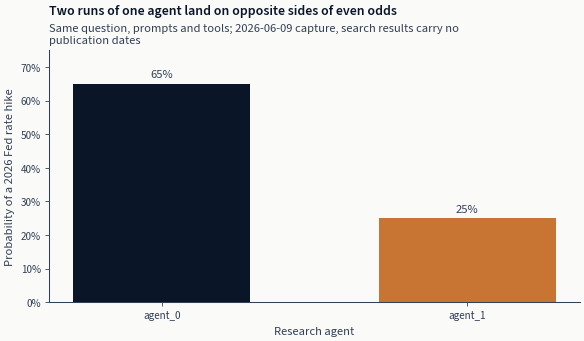

In [27]:
fig, ax = plt.subplots()
bars = ax.bar(
    [a.agent_id for a in pair],
    [a.p_yes for a in pair],
    color=[COLORS["blue"], COLORS["copper"]],
    width=0.58,
)
ax.bar_label(bars, labels=[f"{a.p_yes:.0%}" for a in pair], padding=3)
ax.set_xlabel("Research agent")
ax.set_ylabel("Probability of a 2026 Fed rate hike")
ax.set_ylim(0, max(a.p_yes for a in pair) + 0.10)
format_pct_axis(ax)
add_message_title(
    ax,
    "Two runs of one agent land on opposite sides of even odds",
    subtitle="Same question, prompts and tools; 2026-06-09 capture, "
    "search results carry no publication dates",
)
show_with_alt(
    fig,
    f"Bar chart of two agent forecasts for the same question: {pair[0].agent_id} at "
    f"{pair[0].p_yes:.0%} and {pair[1].agent_id} at {pair[1].p_yes:.0%}, "
    f"{abs(pair[0].p_yes - pair[1].p_yes):.0%} apart.",
)

The two rationales disagree about the level of the policy rate itself, not only about where
it is going, which means at least one of them read something wrong. Neither agent's evidence
carries a publication date, so neither can be checked against what was knowable on the day.
A single agent gives no way to notice any of this: the disagreement is the diagnostic, and it
only exists once there is more than one run to compare.

## Persisting the Run Trace

The artifact holds the structured forecast; the `TracingLLMClient`s wrapped
around each agent hold the raw conversation. `RunTrace.capture` bundles both:
the question, both agents' artifacts, and every prompt/response, into one JSON
record under `forecast_traces/`, the same auditable format the multi-agent
notebooks write. Reload it with `RunTrace.load` to inspect the saved
inputs and outputs, which is what the default `RUN_LIVE = False` path
does above. A live run writes a fresh trace here; the default replay run reports
the pinned trace it loaded rather than overwriting it.

In [28]:
if RUN_LIVE:
    run = RunTrace.capture(
        notebook="04_research_agent",
        provider=provider_name,
        question=question,
        params={"max_steps": MAX_STEPS, "max_search_results": MAX_SEARCH_RESULTS},
        agents=[artifact, artifact_b],
        notes="Single research agent plus a two-agent preview on the contested question.",
        llm_calls=merge_calls(tracer_0, tracer_1),
    )
    trace_path = run.save()
    print(
        f"Saved {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) -> {trace_path.relative_to(trace_path.parents[1])}"
    )
else:
    # Replay: report the pinned trace we loaded rather than writing a new file.
    run = pinned_run
    trace_path = TRACES_DIR / PINNED_TRACE
    print(
        f"Replayed {len(run.llm_calls)} model calls "
        f"({run.total_tokens():,} tokens) from {trace_path.name}"
    )

Replayed 10 model calls (42,266 tokens) from 04_research_agent_20260609T141730Z_b694ab4d0453.json


## Key Takeaways

1. **The artifact is the deliverable, not the number.** A probability with no record of what
   was searched, what came back, and how many turns it took cannot be audited, compared, or
   debugged. Everything the rest of this chapter does - aggregating, debating, scoring - reads
   the artifact, not the model.
2. **Separate what the model said from what was derived from it.** `p_yes` and the rationale
   come from the model; confidence, sentiment, key findings and evidence class are functions
   computed over them. Mixing the two makes an arithmetic transform look like a judgement.
3. **A derived field is only as good as its definition, and most of these are crude.**
   Extremity is not confidence and volume is not quality. They are useful because they are
   cheap, uniform across agents, and inspectable; they are not estimates.
4. **An agent that ran out of turns did not forecast.** `forecast_produced` says which of the
   two a `p_yes` is, and it is the field to read before that probability enters any average.
   A fallback value counted as an opinion is the quietest way a panel gets pulled toward even
   odds by an agent that never spoke.
5. **One class, many agents.** The same `ResearchAgent` with nothing changed but its id is
   the whole mechanism behind the multi-agent system:
   [`06_multi_agent_research`](06_multi_agent_research.ipynb) runs several,
   [`07_adversarial_debate`](07_adversarial_debate.ipynb) makes them argue, and
   [`08_forecasting_pipeline`](08_forecasting_pipeline.ipynb) wires the stages together.

**Known limitations of what is built here.** Confidence is derived from how far the
probability sits from even odds, so a well-evidenced coin-flip is reported as maximally
unconfident and a hallucinated near-certainty as maximally sure. Evidence quality counts
documents and queries and reads nothing, so twenty copies of one wire story score as high.
Key findings are whatever the model happened to format as a list. And a single agent gives
one sample: nothing here bounds how much of the probability is the evidence and how much is
this run's sampling.

**Next**: [`05_aggregation_math`](05_aggregation_math.ipynb) is the arithmetic for combining
several such probabilities into one.

**Book**: Section 24.6 discusses agent design patterns, including the trade-off between
agent complexity and forecast calibration.